# Previsão de Risco de Crédito

## Fase 01 — Análise Exploratória de Dados (EDA)

### Contexto do problema

Uma instituição financeira precisa avaliar o risco associado à concessão
de empréstimos. Neste projeto, será desenvolvido um modelo de Machine Learning
capaz de auxiliar na identificação de clientes com maior risco de inadimplência.

A variável alvo é `loan_status`:

- `0`: cliente não inadimplente;
- `1`: cliente inadimplente.

### Objetivo desta etapa

A Análise Exploratória de Dados tem como objetivo compreender a estrutura,
a qualidade e o comportamento da base antes de qualquer tratamento ou
modelagem.

Nesta etapa serão investigados:

- estrutura e tipos das variáveis;
- estatísticas descritivas;
- valores ausentes e registros duplicados;
- distribuição das variáveis;
- distribuição da variável alvo;
- possíveis valores discrepantes;
- relações e correlações entre as variáveis.

In [2]:
#Importantdo bibliotecas para análise de dados e visualização
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#Lendo o arquivo CSV contendo o dataset de risco de crédito
df = pd.read_csv('../data/credit_risk_dataset.csv')

#visualizando as primeiras linhas do dataset
display(df.head())

#conferindo o tamanho do dataset
print(f"O dataset possui {df.shape[0]} linhas e {df.shape[1]} colunas.")


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


O dataset possui 32581 linhas e 12 colunas.


In [4]:
#Explorando o dataset para entender melhor suas características e estrutura
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.0 MB


A base de dados possui 4 variáveis categorias: person_home_ownership, loan_intent, loan_grade e cb_person_default_on_file 

In [5]:
#Descrobindo estatísticas descritivas do dataset
df.describe().T

,count,mean,std,min,25%,50%,75%,max
person_age,32581.0,27.734600,6.348078,20.00,23.00,26.00,30.00,144.00
person_income,32581.0,66074.848470,61983.119168,4000.00,38500.00,55000.00,79200.00,6000000.00
person_emp_length,31686.0,4.789686,4.142630,0.00,2.00,4.00,7.00,123.00
loan_amnt,32581.0,9589.371106,6322.086646,500.00,5000.00,8000.00,12200.00,35000.00
loan_int_rate,29465.0,11.011695,3.240459,5.42,7.90,10.99,13.47,23.22
loan_status,32581.0,0.218164,0.413006,0.00,0.00,0.00,0.00,1.00
loan_percent_income,32581.0,0.170203,0.106782,0.00,0.09,0.15,0.23,0.83
cb_person_cred_hist_length,32581.0,5.804211,4.055001,2.00,3.00,4.00,8.00,30.00


In [6]:
#Explorando as colunas do tipo string para entender melhor suas características
df.describe(include="str")

,person_home_ownership,loan_intent,loan_grade,cb_person_default_on_file
count,32581,32581,32581,32581
unique,4,6,7,2
top,RENT,EDUCATION,A,N
freq,16446,6453,10777,26836


In [42]:
#Somandos os valores nulos em cada coluna do dataset
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [43]:
dados_ausentes = pd.DataFrame(
    {"Quantidade": df.isnull().sum(),
     "Percentual (%)": (df.isnull().sum() / df.shape[0]) * 100}
)

dados_ausentes[dados_ausentes["Quantidade"] > 0]

,Quantidade,Percentual (%)
person_emp_length,895,2.747000
loan_int_rate,3116,9.563856


In [44]:
#explorando as duplicatas no dataset
df.duplicated().sum()

np.int64(165)

In [47]:
#Explorando a coluna 'loan_status' para entender melhor a distribuição dos valores
df['loan_status'].value_counts()
df['loan_status'].value_counts(normalize=True) * 100

loan_status
0    78.183604
1    21.816396
Name: proportion, dtype: float64

## Primeiras observações da base

A base possui 32.581 registros e 12 variáveis, contendo atributos
numéricos e categóricos relacionados ao perfil dos clientes e às
características dos empréstimos.

Foram identificados valores ausentes em duas variáveis:
`person_emp_length`, com 895 registros ausentes, e `loan_int_rate`,
com 3.116 registros ausentes. A técnica de tratamento desses valores
será definida posteriormente a partir da análise das distribuições.

A estatística descritiva também revelou possíveis valores discrepantes.
A variável `person_age`, por exemplo, apresenta valor máximo de 144 anos,
enquanto 75% dos registros possuem idade de até 30 anos. De forma
semelhante, `person_emp_length` apresenta máximo de 123 anos de vínculo,
apesar de 75% dos valores estarem abaixo de 7 anos. Esses registros serão
investigados por meio de análises gráficas antes da definição de qualquer
tratamento.

A variável `person_income` também apresenta forte amplitude, com mediana
de 55.000 e valor máximo de 6.000.000, sugerindo uma possível distribuição
assimétrica e a presença de valores extremos.

A variável alvo `loan_status` apresenta média aproximada de 0,218. Como
se trata de uma variável binária, esse resultado indica preliminarmente
que cerca de 21,8% das observações pertencem à classe de inadimplência,
sugerindo desbalanceamento entre as classes. Essa distribuição será
investigada diretamente nas próximas etapas da EDA.

Também foram identificados 165 registros duplicados. Nesta etapa nenhuma
remoção, imputação ou transformação foi realizada, pois o objetivo da EDA
é primeiro compreender os problemas existentes antes da definição das
estratégias de tratamento.

In [15]:
#explorando as colunas categóricas do dataset para entender melhor a distribuição dos valores
colunas_categoricas = df.select_dtypes(include="str").columns

for coluna in colunas_categoricas:
    print(f"\n--- {coluna} ---")
    display(df[coluna].value_counts())
    


--- person_home_ownership ---


person_home_ownership
RENT        16446
MORTGAGE    13444
OWN          2584
OTHER         107
Name: count, dtype: int64


--- loan_intent ---


loan_intent
EDUCATION            6453
MEDICAL              6071
VENTURE              5719
PERSONAL             5521
DEBTCONSOLIDATION    5212
HOMEIMPROVEMENT      3605
Name: count, dtype: int64


--- loan_grade ---


loan_grade
A    10777
B    10451
C     6458
D     3626
E      964
F      241
G       64
Name: count, dtype: int64


--- cb_person_default_on_file ---


cb_person_default_on_file
N    26836
Y     5745
Name: count, dtype: int64

In [ ]:
#explorando as colunas categóricas do dataset para entender melhor a distribuição dos valores em percentual
for coluna in colunas_categoricas:
    print(f"\n--- {coluna} (%) ---")
    display((df[coluna].value_counts(normalize=True) * 100).round(2))


--- person_home_ownership (%) ---


person_home_ownership
RENT        50.48
MORTGAGE    41.26
OWN          7.93
OTHER        0.33
Name: proportion, dtype: float64


--- loan_intent (%) ---


loan_intent
EDUCATION            19.81
MEDICAL              18.63
VENTURE              17.55
PERSONAL             16.95
DEBTCONSOLIDATION    16.00
HOMEIMPROVEMENT      11.06
Name: proportion, dtype: float64


--- loan_grade (%) ---


loan_grade
A    33.08
B    32.08
C    19.82
D    11.13
E     2.96
F     0.74
G     0.20
Name: proportion, dtype: float64


--- cb_person_default_on_file (%) ---


cb_person_default_on_file
N    82.37
Y    17.63
Name: proportion, dtype: float64

## Explorando gráficos

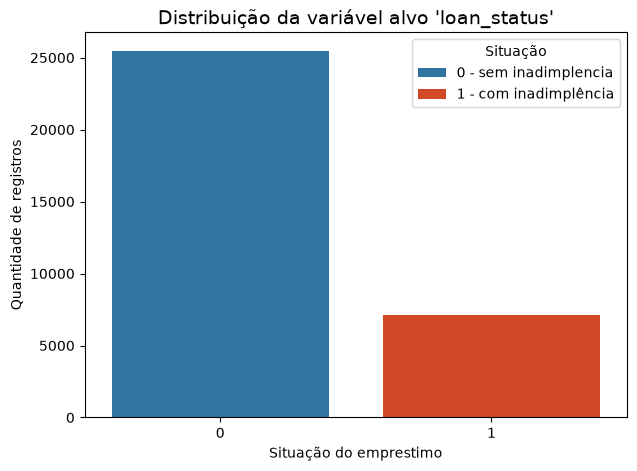

In [26]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x='loan_status',
    hue='loan_status',
    palette=['#1f77b4', "#f03709"]
)

plt.title("Distribuição da variável alvo 'loan_status'", fontsize=14)
plt.xlabel("Situação do emprestimo")    
plt.ylabel("Quantidade de registros")
plt.legend(title = "Situação", loc="upper right", labels = ['0 - sem inadimplencia', '1 - com inadimplência'])
plt.show()

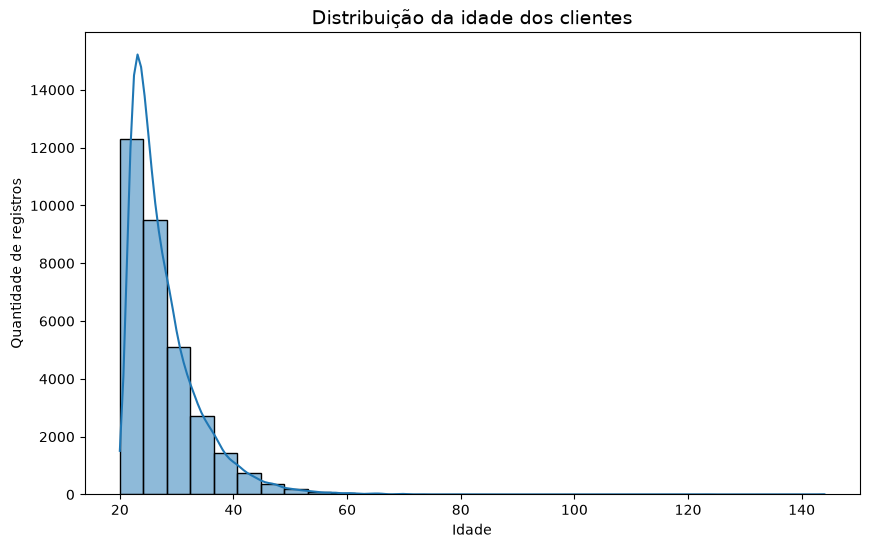

In [27]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="person_age",
    bins=30,
    kde=True,
)
plt.title("Distribuição da idade dos clientes", fontsize=14)
plt.xlabel("Idade")
plt.ylabel("Quantidade de registros")
plt.show()

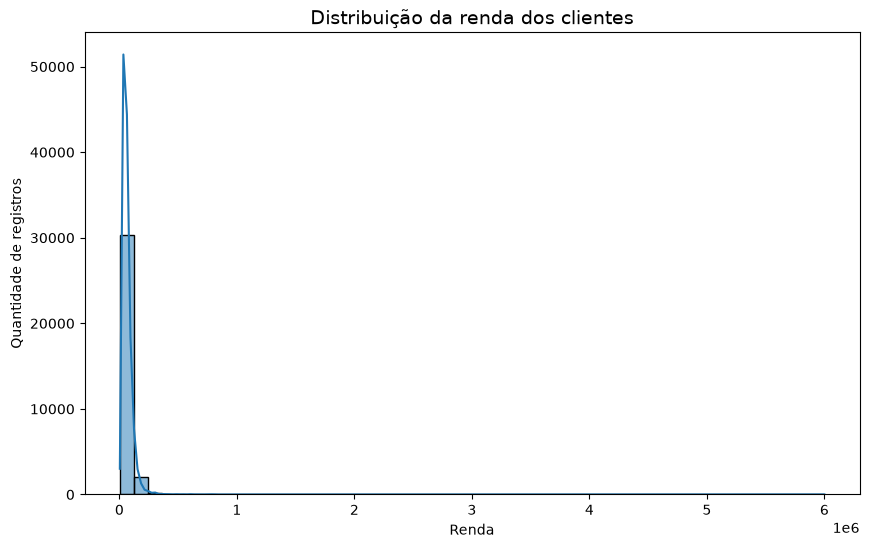

In [28]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x='person_income',
    bins=50,
    kde=True,
)

plt.title("Distribuição da renda dos clientes", fontsize=14)
plt.xlabel("Renda")
plt.ylabel("Quantidade de registros")
plt.show()

Se obervado o valor da mediana da renda dos clientes ficou em 55.000, o que comprova o gráfico estar concentrado em poucos valores a esquerda, além disso o percentil 25 identificado na descrição da base esta girando em torno de 38 mil, tendo poucos valores pequenos. Além disso há a presença de valores de 6 milhões, o que faz com que o eixo x se extenda consideralvemneten.

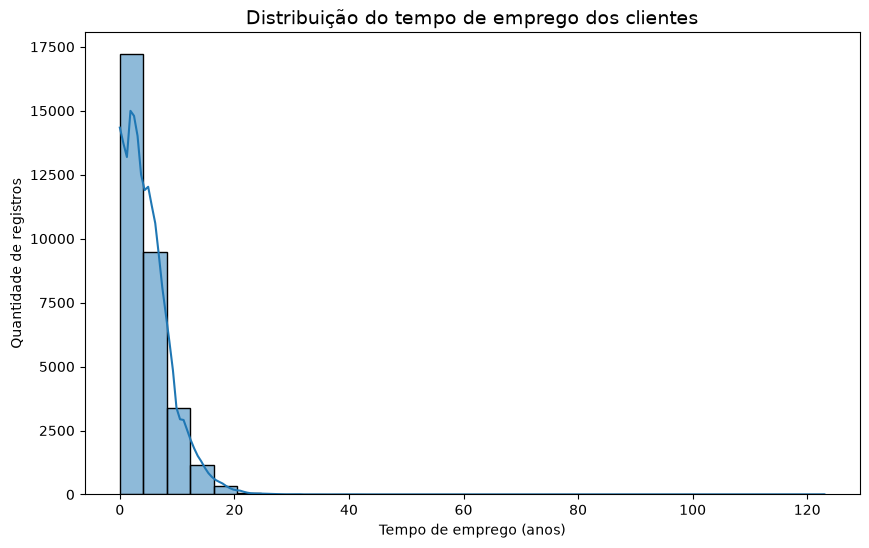

In [30]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x='person_emp_length',
    bins=30,
    kde=True
)
plt.title("Distribuição do tempo de emprego dos clientes", fontsize=14)
plt.xlabel("Tempo de emprego (anos)")
plt.ylabel("Quantidade de registros")
plt.show()

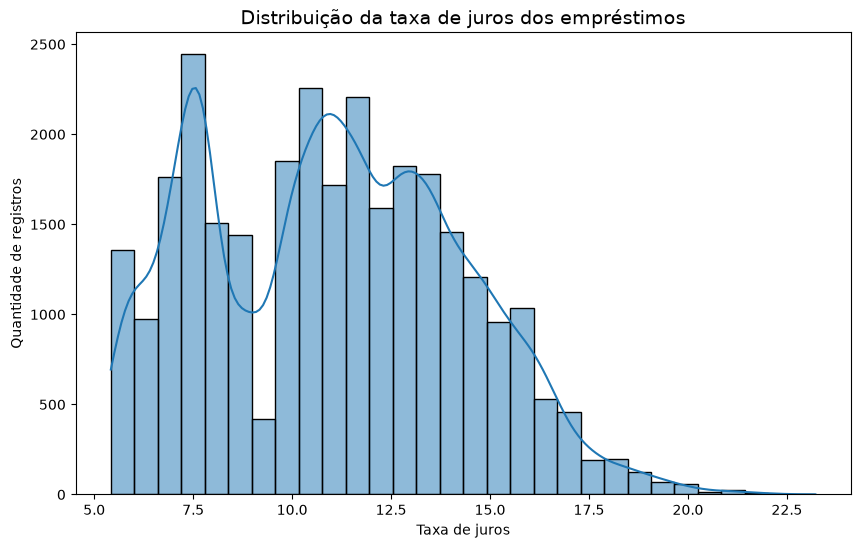

In [32]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x='loan_int_rate',
    bins=30,
    kde=True
)

plt.title("Distribuição da taxa de juros dos empréstimos", fontsize=14)
plt.xlabel("Taxa de juros")
plt.ylabel("Quantidade de registros")
plt.show()

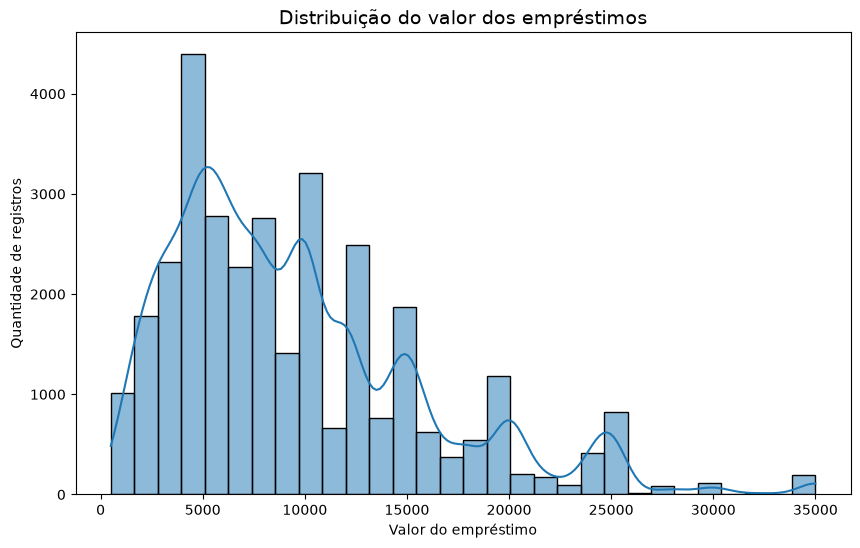

In [33]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="loan_amnt",
    bins=30,
    kde=True    
)

plt.title("Distribuição do valor dos empréstimos", fontsize=14)
plt.xlabel("Valor do empréstimo")
plt.ylabel("Quantidade de registros")
plt.show()

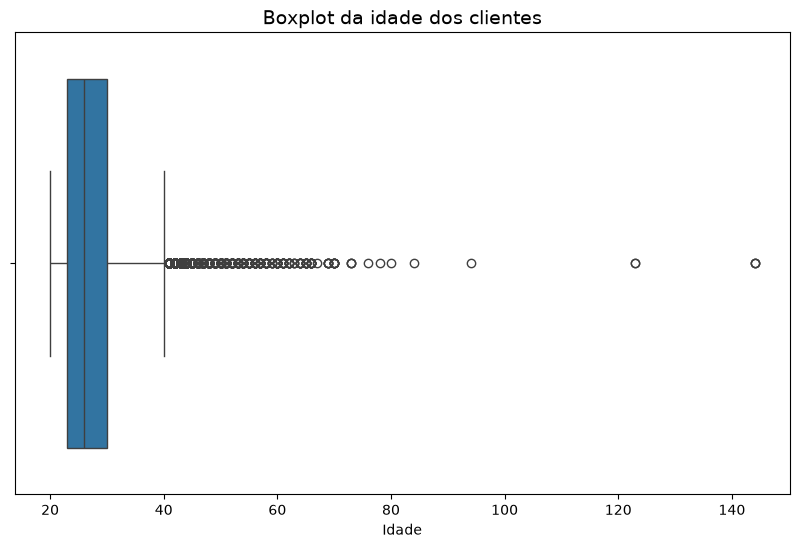

In [34]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='person_age'
)

plt.title("Boxplot da idade dos clientes", fontsize=14)
plt.xlabel("Idade")
plt.show()

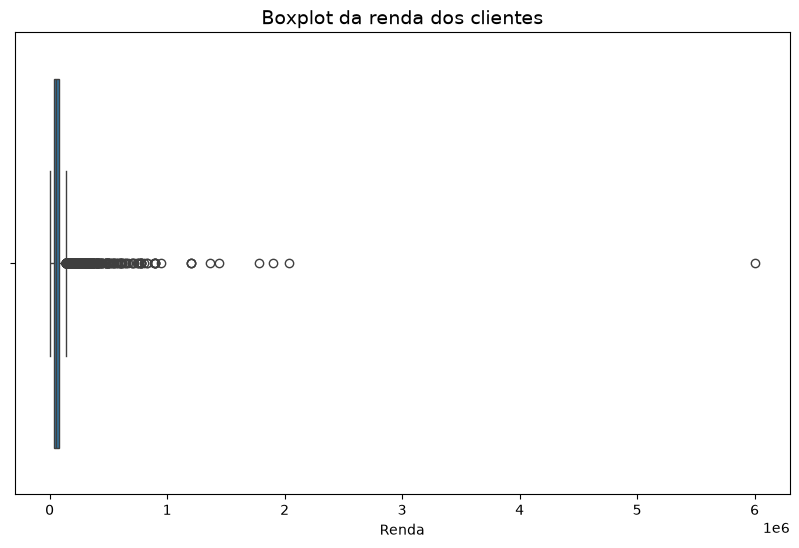

In [35]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='person_income'
)

plt.title("Boxplot da renda dos clientes", fontsize=14)
plt.xlabel("Renda")
plt.show()

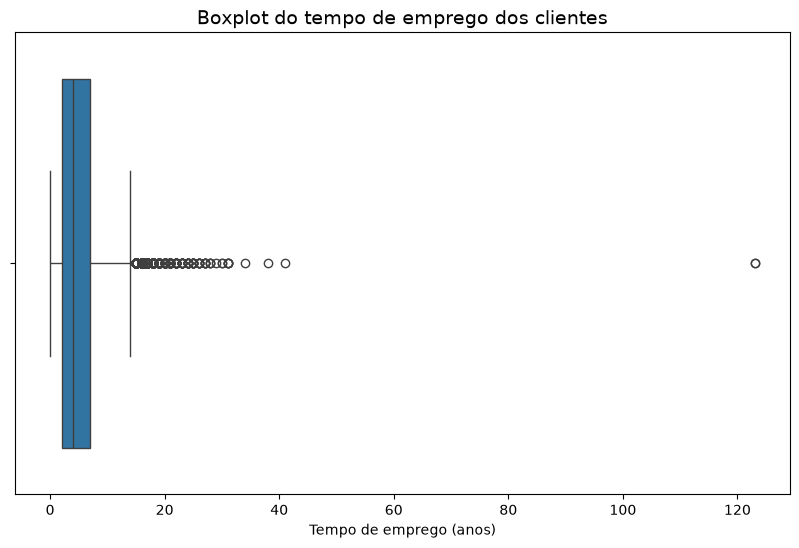

In [36]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='person_emp_length'
)
plt.title("Boxplot do tempo de emprego dos clientes", fontsize=14)
plt.xlabel("Tempo de emprego (anos)")
plt.show()

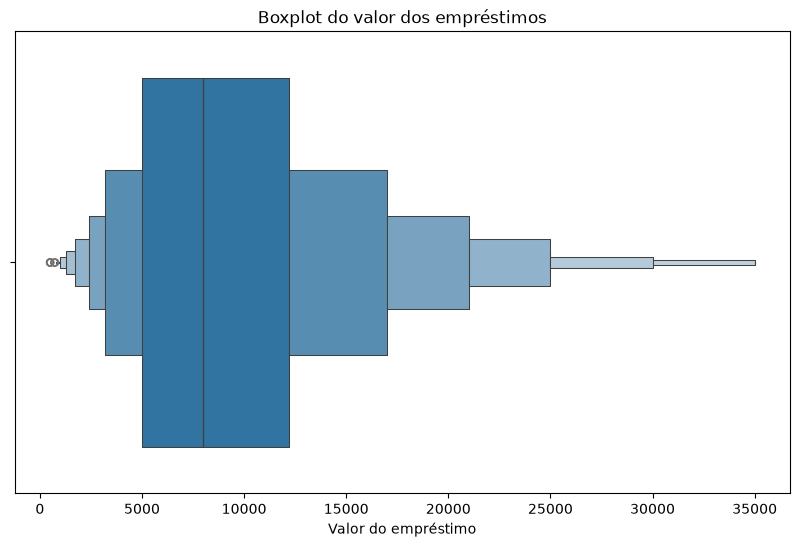

In [39]:
plt.figure(figsize=(10,6))

sns.boxenplot(
    data=df,
    x='loan_amnt'
)

plt.title("Boxplot do valor dos empréstimos")
plt.xlabel("Valor do empréstimo")

plt.show()

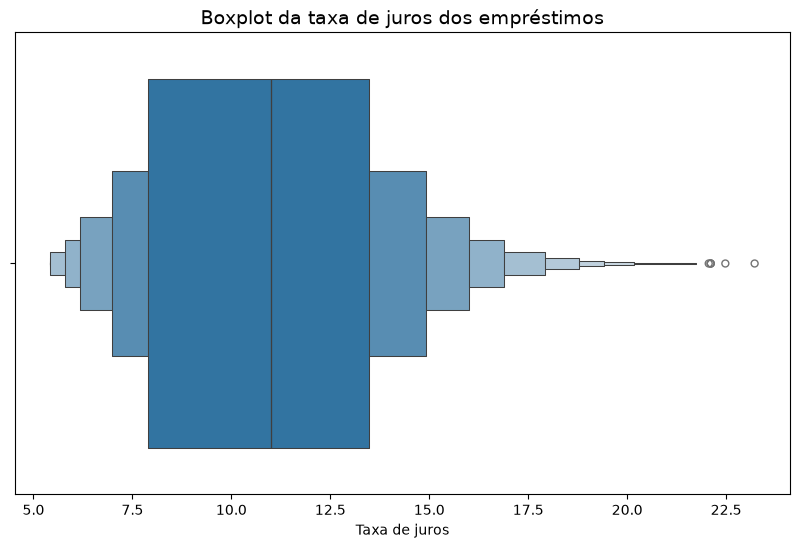

In [37]:
plt.figure(figsize=(10,6))

sns.boxenplot(
    data=df,
    x='loan_int_rate'
)

plt.title("Boxplot da taxa de juros dos empréstimos", fontsize=14)
plt.xlabel("Taxa de juros")
plt.show()

## Análise das distribuições

### Variável alvo

A distribuição da variável loan_status evidencia um desbalanceamento entre as classes. A maior parte dos registros corresponde a clientes sem inadimplência (loan_status = 0), enquanto os clientes inadimplentes (loan_status = 1) representam uma parcela consideravelmente menor da base. Essa característica deverá ser considerada durante a modelagem, pois um modelo pode apresentar boa acurácia simplesmente por favorecer a classe majoritária. Por isso, posteriormente serão avaliadas métricas como precision, recall, F1-score e matriz de confusão, além da aplicação de uma técnica de balanceamento apenas sobre os dados de treinamento.

### Idade

A distribuição da variável loan_status evidencia um desbalanceamento entre as classes. A maior parte dos registros corresponde a clientes sem inadimplência (loan_status = 0), enquanto os clientes inadimplentes (loan_status = 1) representam uma parcela consideravelmente menor da base. Essa característica deverá ser considerada durante a modelagem, pois um modelo pode apresentar boa acurácia simplesmente por favorecer a classe majoritária. Por isso, posteriormente serão avaliadas métricas como precision, recall, F1-score e matriz de confusão, além da aplicação de uma técnica de balanceamento apenas sobre os dados de treinamento.

### Renda

A renda apresenta uma distribuição fortemente assimétrica à direita. A maior parte dos clientes está concentrada em valores relativamente próximos da região inferior da distribuição, enquanto há uma cauda extensa composta por rendas mais elevadas. Essa característica também é percebida pela diferença entre a mediana, de aproximadamente 55 mil, e a média, de aproximadamente 66 mil, além da existência de um valor máximo de 6 milhões. Os valores elevados não podem ser classificados automaticamente como erros, pois rendas muito altas podem ser legítimas, mas deverão ser investigados

### Tempo de emprego

A variável person_emp_length apresenta forte concentração nos primeiros anos de vínculo empregatício, com mediana de 4 anos e 75% dos registros apresentando até 7 anos de emprego. A distribuição é assimétrica à direita e possui diversos valores acima da região central, incluindo observações superiores a 30 e 40 anos e um máximo de 123 anos. Entretanto, valores elevados de tempo de emprego não devem ser considerados inválidos apenas por serem outliers estatísticos, pois podem ser compatíveis com clientes mais velhos. Na etapa de preparação será importante avaliar a consistência entre idade e tempo de emprego, especialmente nos valores extremos.

### Valor do empréstimo

Os valores dos empréstimos apresentam maior dispersão do que variáveis como idade e tempo de emprego. Existe maior concentração nos valores mais baixos e intermediários, especialmente em torno de 5 mil e 10 mil, mas também aparecem concentrações adicionais em diferentes faixas, produzindo vários picos na distribuição. Os empréstimos chegam a 35 mil, e a frequência tende a diminuir à medida que os valores aumentam. Esse comportamento sugere uma distribuição assimétrica à direita e possivelmente influenciada por valores de empréstimo recorrentes ou padronizados.

### Taxa de juros

A distribuição da taxa de juros apresenta múltiplas regiões de concentração, com um pico próximo de 7–8% e outro conjunto expressivo aproximadamente entre 10% e 13%. A partir dessas faixas, a frequência diminui progressivamente, formando uma cauda à direita que alcança valores superiores a 20%. Diferentemente de renda, idade e tempo de emprego, os valores extremos observados parecem menos distantes do restante da distribuição, embora o boxplot identifique algumas observações mais elevadas que deverão ser avaliadas.